<a href="https://colab.research.google.com/github/Rishabh-Sarpal/Valorant-/blob/main/csgo_fuzzy_player_skill_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install scikit-fuzzy seaborn

In [11]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Inputs
kd_ratio = ctrl.Antecedent(np.arange(0, 3.1, 0.1), 'kd_ratio')
accuracy = ctrl.Antecedent(np.arange(0, 101, 1), 'accuracy')
reaction_time = ctrl.Antecedent(np.arange(100, 501, 1), 'reaction_time')

# Output
skill = ctrl.Consequent(np.arange(0, 101, 1), 'skill')

In [12]:
# KD Ratio
kd_ratio['low'] = fuzz.trimf(kd_ratio.universe, [0,0,1])
kd_ratio['medium'] = fuzz.trimf(kd_ratio.universe, [0.8,1.5,2.2])
kd_ratio['high'] = fuzz.trimf(kd_ratio.universe, [1.8,3,3])

# Accuracy
accuracy['poor'] = fuzz.trimf(accuracy.universe,[0,0,40])
accuracy['average'] = fuzz.trimf(accuracy.universe,[30,50,70])
accuracy['good'] = fuzz.trimf(accuracy.universe,[60,100,100])

# Reaction Time
reaction_time['slow'] = fuzz.trimf(reaction_time.universe,[300,500,500])
reaction_time['normal'] = fuzz.trimf(reaction_time.universe,[200,300,400])
reaction_time['fast'] = fuzz.trimf(reaction_time.universe,[100,100,250])

# Skill Level
skill['beginner'] = fuzz.trimf(skill.universe,[0,0,40])
skill['intermediate'] = fuzz.trimf(skill.universe,[30,50,70])
skill['pro'] = fuzz.trimf(skill.universe,[60,100,100])

In [13]:
rule1 = ctrl.Rule(kd_ratio['low'] & accuracy['poor'], skill['beginner'])

rule2 = ctrl.Rule(kd_ratio['medium'] & accuracy['average'],
                  skill['intermediate'])

rule3 = ctrl.Rule(kd_ratio['high'] & accuracy['good'] &
                  reaction_time['fast'], skill['pro'])

rule4 = ctrl.Rule(kd_ratio['high'] & accuracy['average'],
                  skill['intermediate'])

rule5 = ctrl.Rule(kd_ratio['medium'] & reaction_time['fast'],
                  skill['intermediate'])

rule6 = ctrl.Rule(accuracy['good'] & reaction_time['fast'],
                  skill['pro'])

In [14]:
skill_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6
])

skill_sim = ctrl.ControlSystemSimulation(skill_ctrl)

In [15]:
kd_input = float(input("Enter KD Ratio: "))
accuracy_input = float(input("Enter Accuracy (%): "))
reaction_input = float(input("Enter Reaction Time (ms): "))

skill_sim.input['kd_ratio'] = kd_input
skill_sim.input['accuracy'] = accuracy_input
skill_sim.input['reaction_time'] = reaction_input

skill_sim.compute()

score = skill_sim.output['skill']

print("Player Skill Score:", score)

Enter KD Ratio: 2
Enter Accuracy (%): 32
Enter Reaction Time (ms): 1
Player Skill Score: 50.0


In [16]:
def get_rank(score):

    if score < 30:
        return "Silver"

    elif score < 50:
        return "Gold Nova"

    elif score < 70:
        return "Master Guardian"

    elif score < 85:
        return "Legendary Eagle"

    else:
        return "Global Elite"

print("Player Rank:", get_rank(score))

Player Rank: Master Guardian


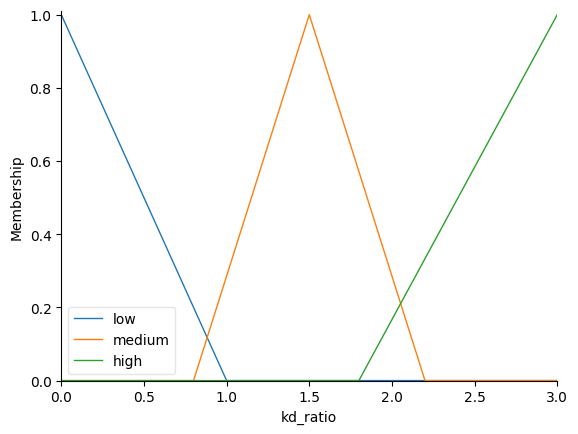

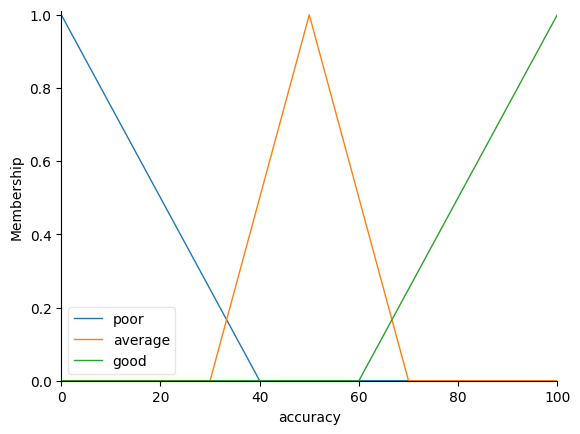

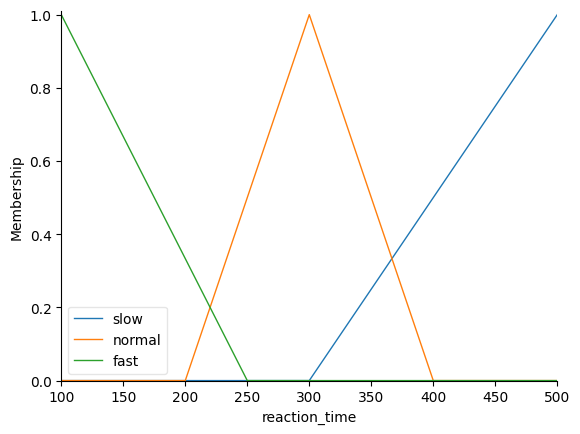

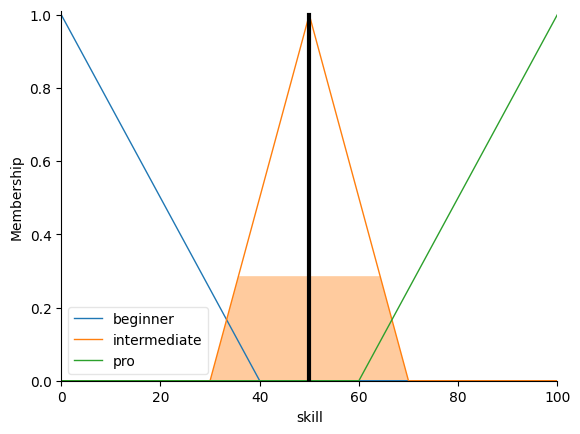

In [17]:
kd_ratio.view()
accuracy.view()
reaction_time.view()
skill.view(sim=skill_sim)

In [19]:
players = []

for i in range(100):

    kd = np.random.uniform(0.5,2.5)
    acc = np.random.uniform(30,90)
    react = np.random.uniform(150,400)

    sim = ctrl.ControlSystemSimulation(skill_ctrl)

    sim.input['kd_ratio'] = kd
    sim.input['accuracy'] = acc
    sim.input['reaction_time'] = react

    sim.compute()

    # Use .get() to safely retrieve the 'skill' output, defaulting to 0 if not found
    score = sim.output.get('skill', 0)

    players.append([kd,acc,react,score])

df = pd.DataFrame(players,columns=[
    "KD Ratio","Accuracy","Reaction Time","Skill Score"
])

df.head()

,KD Ratio,Accuracy,Reaction Time,Skill Score
0,2.495949,57.630810,273.204627,50.0
1,0.760189,50.123193,374.482453,0.0
2,2.129492,88.334508,383.110622,0.0
3,2.492756,74.944136,384.824239,0.0
4,1.244888,56.669812,378.512088,50.0


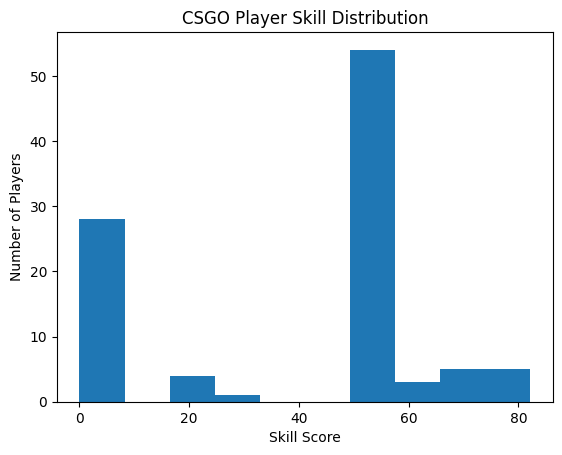

In [20]:
plt.figure()

plt.hist(df["Skill Score"], bins=10)

plt.title("CSGO Player Skill Distribution")
plt.xlabel("Skill Score")
plt.ylabel("Number of Players")

plt.show()

/tmp/ipykernel_140/2828467659.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


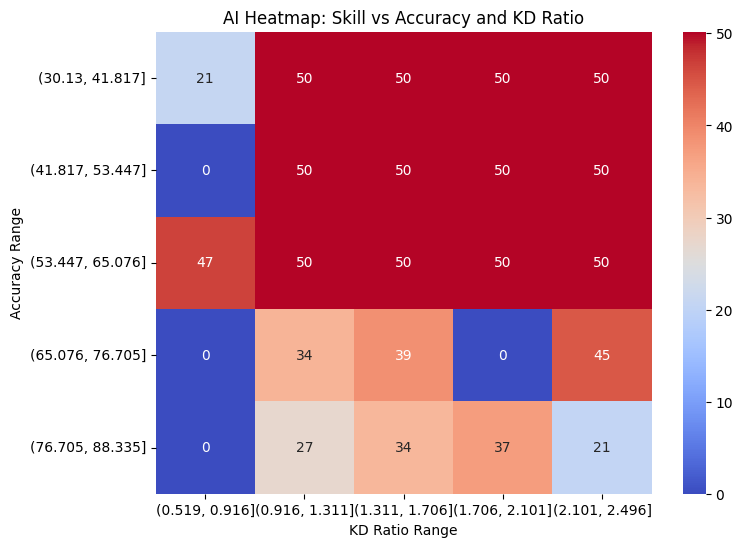

In [21]:
pivot_table = df.pivot_table(
    values="Skill Score",
    index=pd.cut(df["Accuracy"], bins=5),
    columns=pd.cut(df["KD Ratio"], bins=5),
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(pivot_table,
            annot=True,
            cmap="coolwarm")

plt.title("AI Heatmap: Skill vs Accuracy and KD Ratio")
plt.xlabel("KD Ratio Range")
plt.ylabel("Accuracy Range")

plt.show()

/tmp/ipykernel_140/2029589499.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_rt = df.pivot_table(


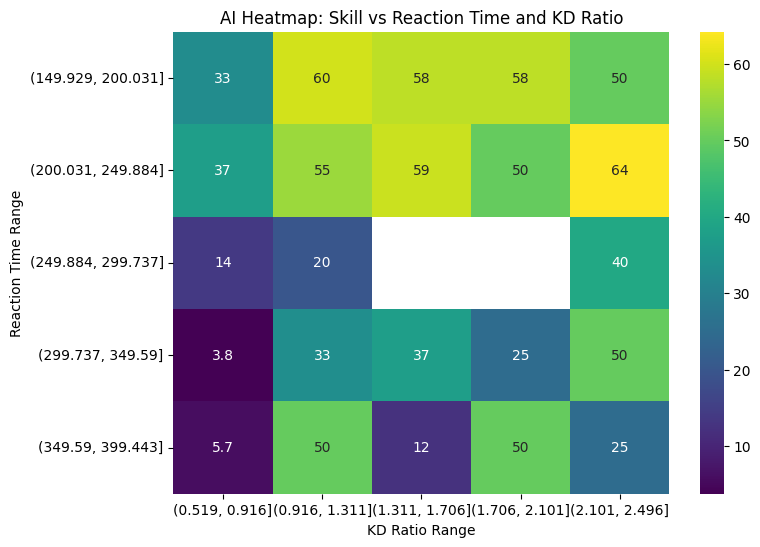

In [22]:
pivot_table_rt = df.pivot_table(
    values="Skill Score",
    index=pd.cut(df["Reaction Time"], bins=5),
    columns=pd.cut(df["KD Ratio"], bins=5),
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(pivot_table_rt,
            annot=True,
            cmap="viridis")

plt.title("AI Heatmap: Skill vs Reaction Time and KD Ratio")
plt.xlabel("KD Ratio Range")
plt.ylabel("Reaction Time Range")

plt.show()